In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sqlalchemy import create_engine, text

# Set the visual style
sns.set_theme(style="darkgrid")
plt.rcParams["figure.figsize"] = (14, 6)
plt.rcParams["font.size"] = 11

Matplotlib is building the font cache; this may take a moment.


In [3]:
engine = create_engine("sqlite:///../data/fred_data.db")

df = pd.read_sql(text("SELECT * FROM macro_series ORDER BY date"), 
                 con=engine.connect())

# Convert date column to a proper datetime type
df["date"] = pd.to_datetime(df["date"])
df = df.set_index("date")

print(df.shape)
df.head()

(2282, 6)


,fed_funds_rate,commercial_loans,consumer_credit,mortgage_rate_30yr,credit_card_delinquency,cpi
date,,,,,,
1990-01-01,8.23,635.7875,797714.86,NaN,NaN,127.5
1990-01-05,NaN,NaN,NaN,9.83,NaN,NaN
1990-01-12,NaN,NaN,NaN,9.80,NaN,NaN
1990-01-19,NaN,NaN,NaN,9.90,NaN,NaN
1990-01-26,NaN,NaN,NaN,10.05,NaN,NaN


In [4]:
# Forward fill: carries the last known value forward to fill gaps
df_clean = df.copy()
df_clean = df_clean.resample("MS").mean()  # Resample everything to monthly
df_clean = df_clean.ffill()               # Forward fill any remaining gaps
df_clean = df_clean.dropna()              # Drop any rows still missing

print(f"Rows before cleaning: {len(df)}")
print(f"Rows after cleaning:  {len(df_clean)}")
df_clean.head()

Rows before cleaning: 2282
Rows after cleaning:  426


,fed_funds_rate,commercial_loans,consumer_credit,mortgage_rate_30yr,credit_card_delinquency,cpi
date,,,,,,
1991-01-01,6.91,636.1319,806600.50,9.6375,5.26,134.7
1991-02-01,6.25,635.9164,807030.43,9.3650,5.26,134.8
1991-03-01,6.12,635.2190,808351.83,9.5000,5.26,134.8
1991-04-01,5.91,631.3454,807818.95,9.4925,5.48,135.1
1991-05-01,5.78,627.7868,807832.16,9.4720,5.48,135.6


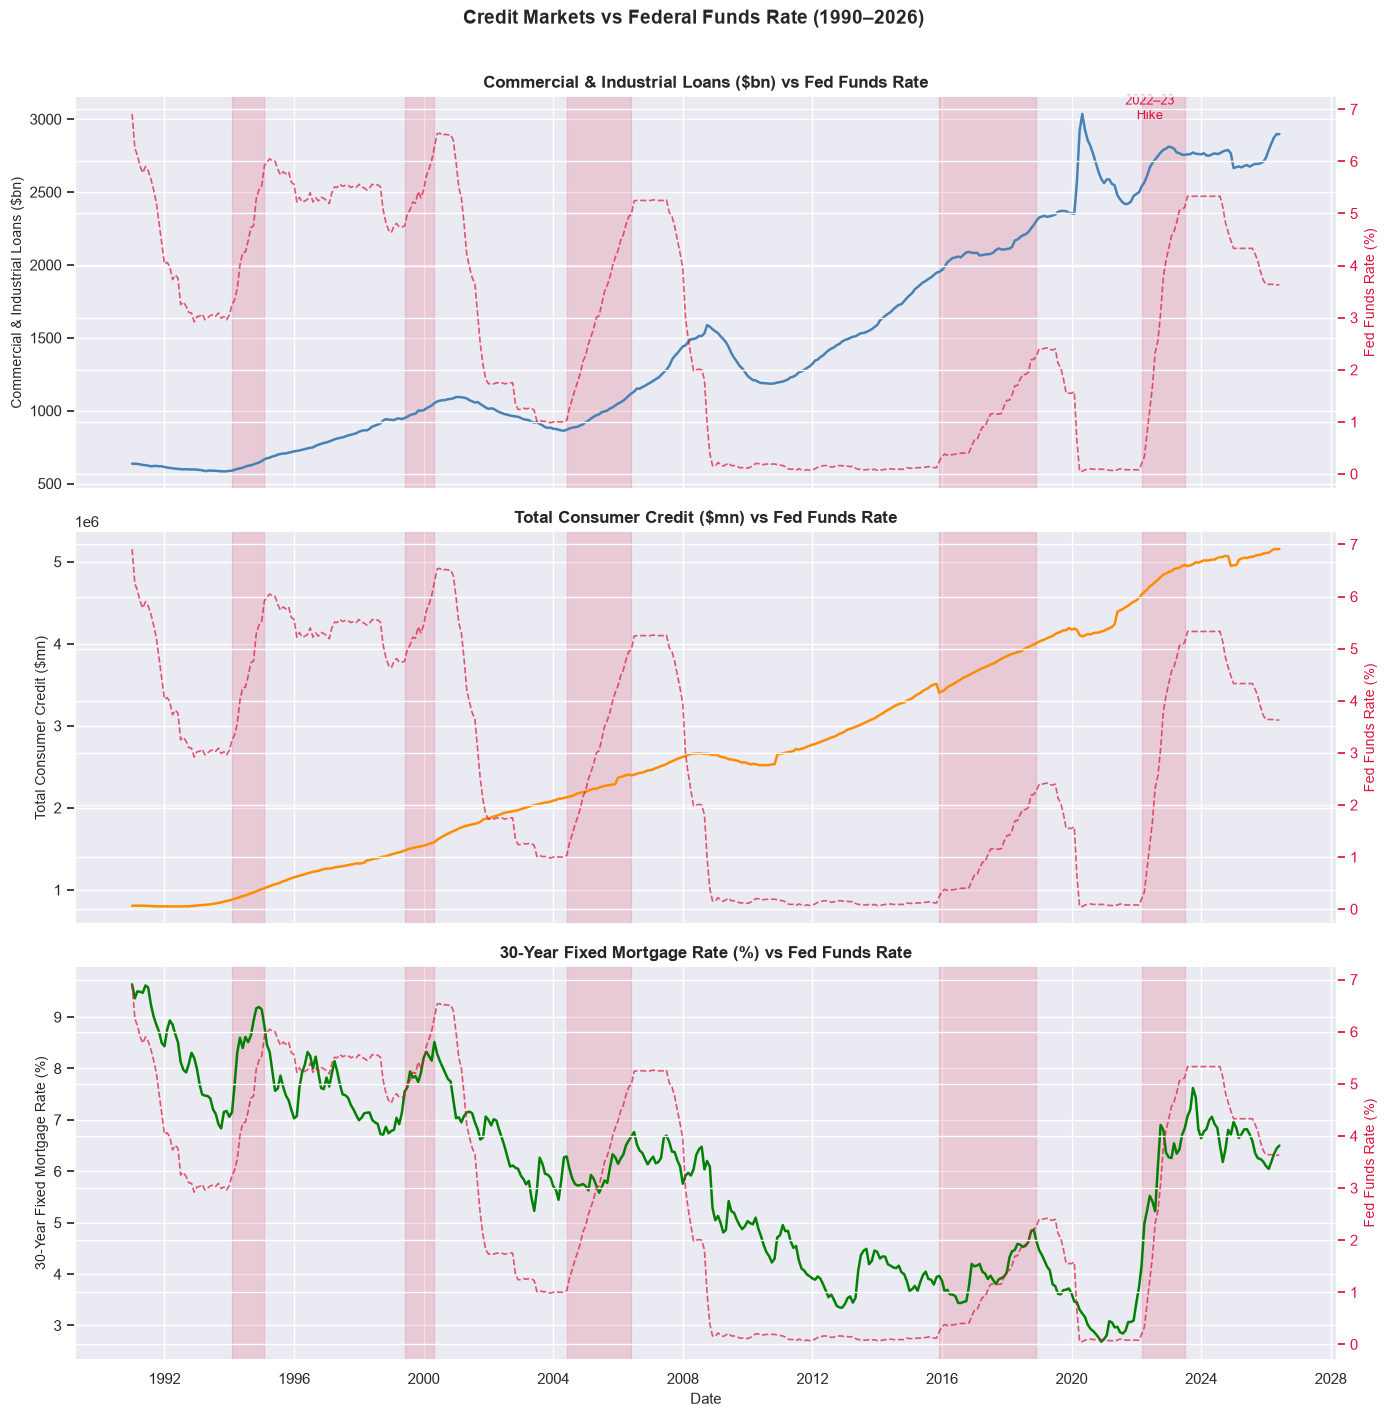

Chart saved to data/chart_credit_vs_rates.png


In [5]:
# Define the major Fed hiking cycles as (start, end, label)
hiking_cycles = [
    ("1994-02-01", "1995-02-01", "1994–95"),
    ("1999-06-01", "2000-05-01", "1999–00"),
    ("2004-06-01", "2006-06-01", "2004–06"),
    ("2015-12-01", "2018-12-01", "2015–18"),
    ("2022-03-01", "2023-07-01", "2022–23"),
]

fig, axes = plt.subplots(3, 1, figsize=(14, 14), sharex=True)

series_to_plot = [
    ("commercial_loans",   "Commercial & Industrial Loans ($bn)",  "steelblue"),
    ("consumer_credit",    "Total Consumer Credit ($mn)",          "darkorange"),
    ("mortgage_rate_30yr", "30-Year Fixed Mortgage Rate (%)",      "green"),
]

for ax, (col, label, colour) in zip(axes, series_to_plot):
    # Plot the credit series on the left axis
    ax.plot(df_clean.index, df_clean[col], color=colour, linewidth=1.8, label=label)
    ax.set_ylabel(label, fontsize=10)

    # Plot Fed Funds rate on a second axis on the right
    ax2 = ax.twinx()
    ax2.plot(df_clean.index, df_clean["fed_funds_rate"], 
             color="crimson", linewidth=1.2, linestyle="--", alpha=0.7, label="Fed Funds Rate")
    ax2.set_ylabel("Fed Funds Rate (%)", fontsize=10, color="crimson")
    ax2.tick_params(axis="y", colors="crimson")

    # Shade each hiking cycle
    for start, end, cycle_label in hiking_cycles:
        ax.axvspan(pd.Timestamp(start), pd.Timestamp(end), 
                   alpha=0.15, color="crimson", label=cycle_label)

    # Label the 2022-23 cycle on the top chart only
    if col == "commercial_loans":
        ax.text(pd.Timestamp("2022-06-01"), ax.get_ylim()[1] * 0.95, 
                "2022–23\nHike", fontsize=9, color="crimson", ha="center")

    ax.set_title(f"{label} vs Fed Funds Rate", fontweight="bold")

axes[-1].set_xlabel("Date", fontsize=11)
fig.suptitle("Credit Markets vs Federal Funds Rate (1990–2026)", 
             fontsize=14, fontweight="bold", y=1.01)

plt.tight_layout()
plt.savefig("../data/chart_credit_vs_rates.png", dpi=150, bbox_inches="tight")
plt.show()

print("Chart saved to data/chart_credit_vs_rates.png")

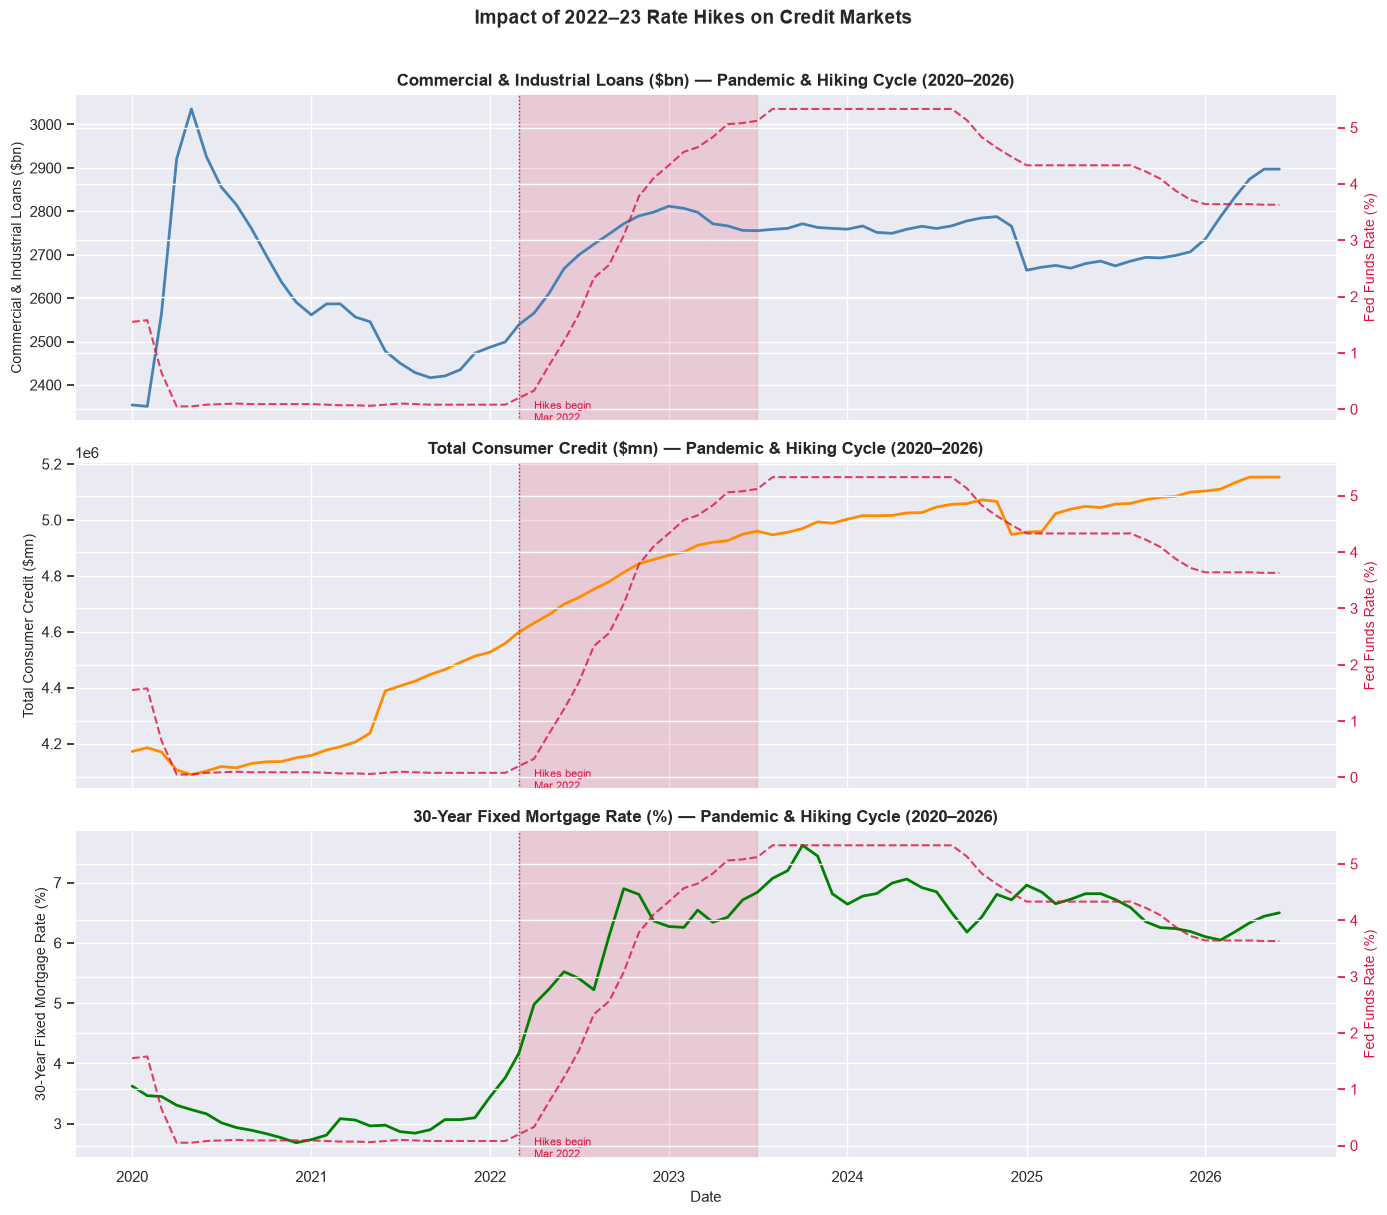

Chart saved.


In [6]:
# Zoom into the 2020-2026 period to focus on the pandemic and hiking cycle
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

# Filter to just the recent period
recent = df_clean["2020-01-01":"2026-06-01"]

series_to_plot = [
    ("commercial_loans",   "Commercial & Industrial Loans ($bn)",  "steelblue"),
    ("consumer_credit",    "Total Consumer Credit ($mn)",          "darkorange"),
    ("mortgage_rate_30yr", "30-Year Fixed Mortgage Rate (%)",      "green"),
]

for ax, (col, label, colour) in zip(axes, series_to_plot):
    ax.plot(recent.index, recent[col], color=colour, linewidth=2, label=label)
    ax.set_ylabel(label, fontsize=10)

    # Fed Funds on right axis
    ax2 = ax.twinx()
    ax2.plot(recent.index, recent["fed_funds_rate"],
             color="crimson", linewidth=1.5, linestyle="--", alpha=0.8)
    ax2.set_ylabel("Fed Funds Rate (%)", color="crimson", fontsize=10)
    ax2.tick_params(axis="y", colors="crimson")

    # Shade the hiking cycle
    ax.axvspan(pd.Timestamp("2022-03-01"), pd.Timestamp("2023-07-01"),
               alpha=0.15, color="crimson")

    # Mark the start of hikes
    ax.axvline(pd.Timestamp("2022-03-01"), color="crimson", 
               linewidth=1, linestyle=":")
    ax.text(pd.Timestamp("2022-04-01"), ax.get_ylim()[0], 
            "Hikes begin\nMar 2022", fontsize=8, color="crimson")

    ax.set_title(f"{label} — Pandemic & Hiking Cycle (2020–2026)", fontweight="bold")

axes[-1].set_xlabel("Date", fontsize=11)
fig.suptitle("Impact of 2022–23 Rate Hikes on Credit Markets", 
             fontsize=14, fontweight="bold", y=1.01)

plt.tight_layout()
plt.savefig("../data/chart_2022_hiking_cycle.png", dpi=150, bbox_inches="tight")
plt.show()

print("Chart saved.")